# CustomerLens — Customer Segmentation via K-Means Clustering

## Unsupervised Behavioral Segmentation in Continuous 3D RFM Feature Space

---

### Executive Objectives & Analytical Scope

In **Phase 8**, we established the customer-level **RFM (Recency, Frequency, Monetary)** feature layer and formulated a rule-based heuristic segmentation. While heuristic scoring provides an intuitive operational scorecard, it relies on rigid rectangular cutoffs.

The objective of **Phase 9** is to apply unsupervised machine learning (**K-Means Clustering**) to discover natural, data-driven geometric customer groupings:
1. **Mathematical Objective:** Partition $N = 4,338$ customer accounts into $K$ cohesive, well-separated clusters by minimizing within-cluster sum of squares (Inertia).
2. **Feature Engineering & Transformation:** Address heavy positive skewness in Frequency and Monetary spend via variance-stabilizing $\log(x + 1)$ transformations.
3. **Isotropic Standardization:** Standardize features using `StandardScaler` ($\mu = 0, \sigma = 1$) so that Euclidean distance reflects relative standard deviations across all dimensions.
4. **Empirical Model Selection:** Evaluate $K = 2 \dots 10$ using Inertia (Elbow Method), Silhouette Analysis, cluster size balance, and commercial interpretability to select a statistically defensible and operationally actionable $K$.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

# Ensure project root is on sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.clustering import (
    load_rfm_data,
    validate_clustering_data,
    prepare_features,
    transform_features,
    scale_features,
    evaluate_k_values,
    select_k,
    fit_kmeans,
    generate_cluster_assignments,
    profile_clusters,
    save_clustering_outputs,
    SELECTED_K,
)

# Plotting style configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.labelweight": "bold",
    "figure.titlesize": 14,
    "figure.titleweight": "bold",
    "figure.dpi": 150,
})

print("Environment configured successfully. Ready for K-Means clustering.")


Environment configured successfully. Ready for K-Means clustering.


---

## 1. Data Ingestion & Invariant Verification

We load the customer-level dataset (`data/processed/rfm_customer_metrics.csv`) generated in Phase 8 and verify baseline data invariants:
- **Total Accounts:** 4,338 unique customers
- **Zero Missing Values:** CustomerID, Recency, Frequency, Monetary are 100% complete
- **Positive Bounds:** Recency $\ge 0$, Frequency $\ge 1$, Monetary $> 0$


In [2]:
rfm_df = load_rfm_data()
validate_clustering_data(rfm_df)

print("=" * 60)
print("RFM INPUT DATASET VERIFICATION")
print("=" * 60)
print(f"Total Customer Accounts : {len(rfm_df):,}")
print(f"Unique Customer IDs     : {rfm_df['customerid'].nunique():,}")
print(f"Missing Values Check    :\n{rfm_df[['recency', 'frequency', 'monetary']].isna().sum().to_dict()}")
print(f"Total Portfolio Revenue : £{rfm_df['monetary'].sum():,.2f}")
print(f"Total Order Volume      : {rfm_df['frequency'].sum():,} orders")
print("=" * 60)

display(rfm_df.head())


RFM INPUT DATASET VERIFICATION
Total Customer Accounts : 4,338
Unique Customer IDs     : 4,338
Missing Values Check    :
{'recency': 0, 'frequency': 0, 'monetary': 0}
Total Portfolio Revenue : £8,887,208.89
Total Order Volume      : 18,532 orders


,customerid,recency,frequency,monetary,first_purchase_date,last_purchase_date,country,R_score,F_score,M_score,RFM_score,segment
0,14646,2,73,280206.02,2010-12-20 10:09:00,2011-12-08 12:12:00,Netherlands,5,4,5,545,Champions
1,18102,1,60,259657.30,2010-12-07 16:42:00,2011-12-09 11:50:00,United Kingdom,5,4,5,545,Champions
2,17450,8,46,194390.79,2010-12-07 09:23:00,2011-12-01 13:29:00,United Kingdom,5,4,5,545,Champions
3,16446,1,2,168472.50,2011-05-18 09:52:00,2011-12-09 09:15:00,United Kingdom,5,1,5,515,Recent Customers
4,14911,1,201,143711.17,2010-12-01 14:05:00,2011-12-08 15:54:00,EIRE,5,4,5,545,Champions


---

## 2. RFM Feature Distributions & Variance-Stabilizing Transformation

### The Need for Feature Transformation in K-Means
K-Means calculates straight-line Euclidean distance:
$$d(x, c) = \sqrt{(x_R - c_R)^2 + (x_F - c_F)^2 + (x_M - c_M)^2}$$
When features exhibit heavy right-skewness:
- The top 1% extreme spenders stretch the distance metric, acting as geometric outliers that pull cluster centroids away from the core distribution.
- Standard deviations are artificially inflated.

We evaluate feature skewness before and after applying $\log(x + 1)$:


,Raw Feature,Raw Skewness,Transformed Feature,Log1p Skewness
0,recency,1.25,recency_log,-0.38
1,frequency,12.07,frequency_log,1.21
2,monetary,19.34,monetary_log,0.40


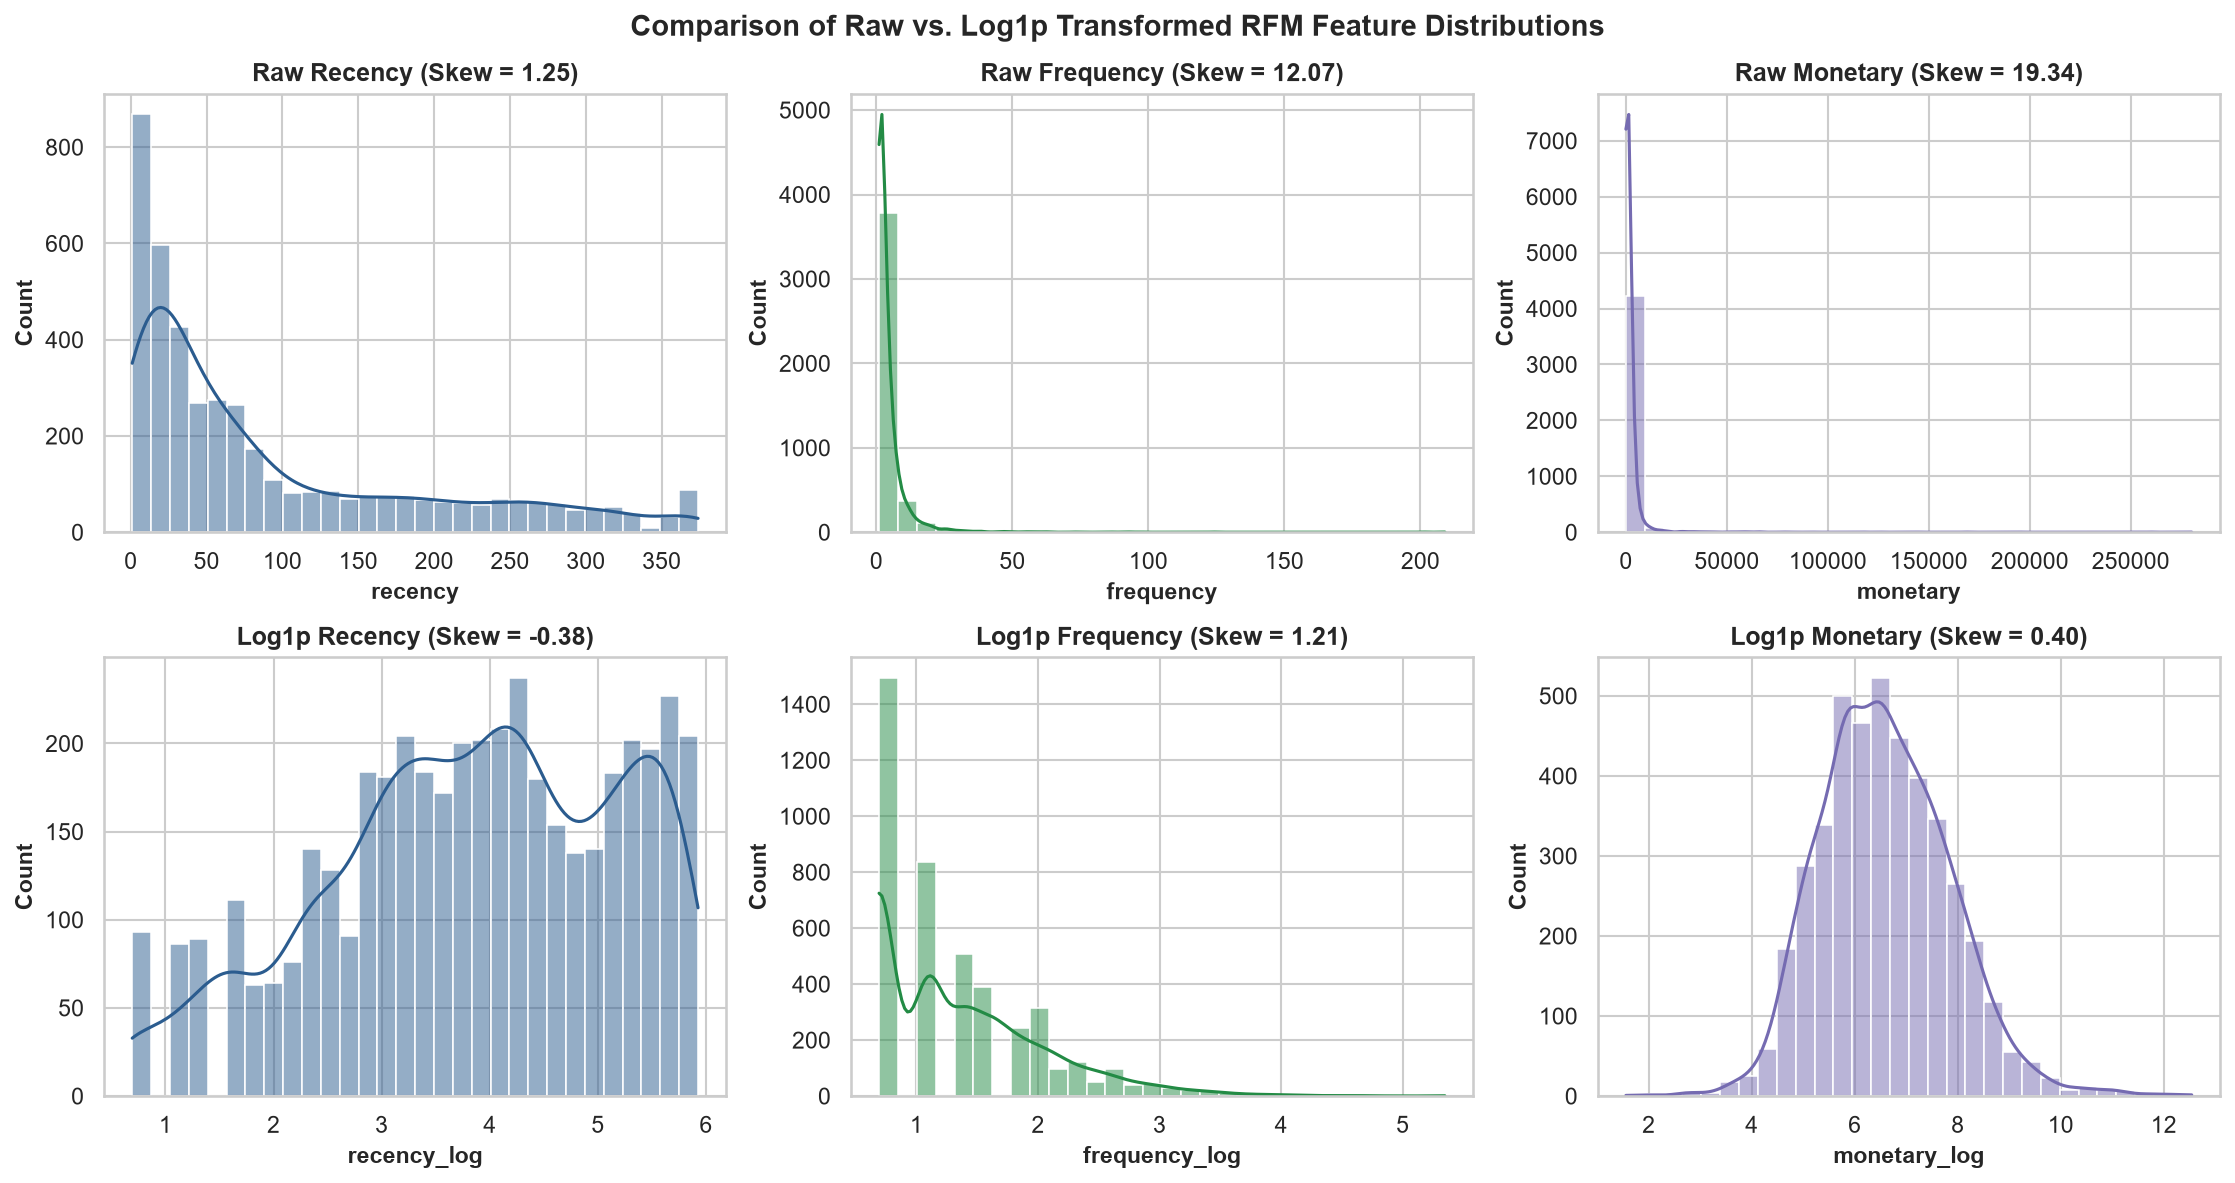

In [3]:
X_raw = prepare_features(rfm_df)
X_log = transform_features(X_raw)

skew_comparison = pd.DataFrame({
    "Raw Feature": X_raw.columns,
    "Raw Skewness": [X_raw[c].skew() for c in X_raw.columns],
    "Transformed Feature": X_log.columns,
    "Log1p Skewness": [X_log[c].skew() for c in X_log.columns],
}).round(2)

display(skew_comparison)

# Visualizing before vs after distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Comparison of Raw vs. Log1p Transformed RFM Feature Distributions", fontsize=14)

colors = ["#2b5c8f", "#238b45", "#756bb1"]

for i, col in enumerate(X_raw.columns):
    sns.histplot(X_raw[col], kde=True, color=colors[i], ax=axes[0, i], bins=30)
    axes[0, i].set_title(f"Raw {col.capitalize()} (Skew = {X_raw[col].skew():.2f})")
    
    sns.histplot(X_log[f"{col}_log"], kde=True, color=colors[i], ax=axes[1, i], bins=30)
    axes[1, i].set_title(f"Log1p {col.capitalize()} (Skew = {X_log[f'{col}_log'].skew():.2f})")

plt.tight_layout()
plt.show()


---

## 3. Feature Standardization (`StandardScaler`)

Even after logarithmic transformation, features operate on different scales:
- $\log(\text{Recency} + 1) \in [0.69, 5.93]$
- $\log(\text{Frequency} + 1) \in [0.69, 5.35]$
- $\log(\text{Monetary} + 1) \in [1.56, 12.54]$

We apply `StandardScaler` to ensure each feature has $\mu = 0$ and $\sigma = 1$, preventing Monetary from exerting disproportionate geometric weight during distance calculations.


In [4]:
X_scaled, scaler = scale_features(X_log)

scaled_df = pd.DataFrame(X_scaled, columns=["R_scaled", "F_scaled", "M_scaled"])

print("Standardized Feature Properties:")
print(f"Means : {np.round(X_scaled.mean(axis=0), 6)}")
print(f"Stds  : {np.round(X_scaled.std(axis=0), 6)}")
display(scaled_df.describe().round(3))


Standardized Feature Properties:
Means : [ 0.  0. -0.]
Stds  : [1. 1. 1.]


,R_scaled,F_scaled,M_scaled
count,4338.000,4338.000,4338.000
mean,0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-2.341,-0.955,-3.998
25%,-0.661,-0.955,-0.684
50%,0.090,-0.362,-0.065
75%,0.845,0.653,0.657
max,1.564,5.859,4.732


---

## 4. Multi-Criteria Evaluation Across $K = 2 \dots 10$

To avoid arbitrarily guessing $K=5$, we systematically evaluate cluster candidates from $K = 2$ through $K = 10$ using fixed `random_state=42` and `n_init=10`.
For each $K$, we record:
1. **Inertia:** Sum of squared Euclidean distances to the closest centroid (Elbow Method).
2. **Silhouette Score:** Mean silhouette coefficient measuring how well each sample is separated from neighboring clusters $[-1, 1]$.
3. **Calinski-Harabasz Index:** Ratio of between-cluster dispersion to within-cluster dispersion (higher is better).
4. **Davies-Bouldin Index:** Similarity measure between each cluster and its most similar one (lower is better).
5. **Cluster Size Balance:** Minimum and maximum cluster membership count.


In [5]:
metrics_df = evaluate_k_values(X_scaled, k_range=range(2, 11), random_state=42, n_init=10)
display(metrics_df)


,k,inertia,silhouette_score,calinski_harabasz,davies_bouldin,cluster_count,min_cluster_size,max_cluster_size
0,2,6483.60,0.4328,4367.32,0.8925,2,1667,2671
1,3,4869.58,0.3369,3625.25,1.0471,3,763,1877
2,4,3939.26,0.3374,3328.14,1.0086,4,716,1618
3,5,3297.20,0.3161,3192.43,0.9880,5,330,1185
4,6,2855.27,0.3142,3082.59,1.0134,6,305,987
5,7,2548.86,0.3092,2963.76,0.9826,7,229,891
6,8,2336.45,0.3012,2826.87,0.9923,8,217,847
7,9,2166.75,0.2934,2709.07,1.0316,9,182,790
8,10,2000.54,0.2783,2647.45,1.0214,10,93,641


---

## 5. Diagnostic Plots: Elbow Curve & Silhouette Profile


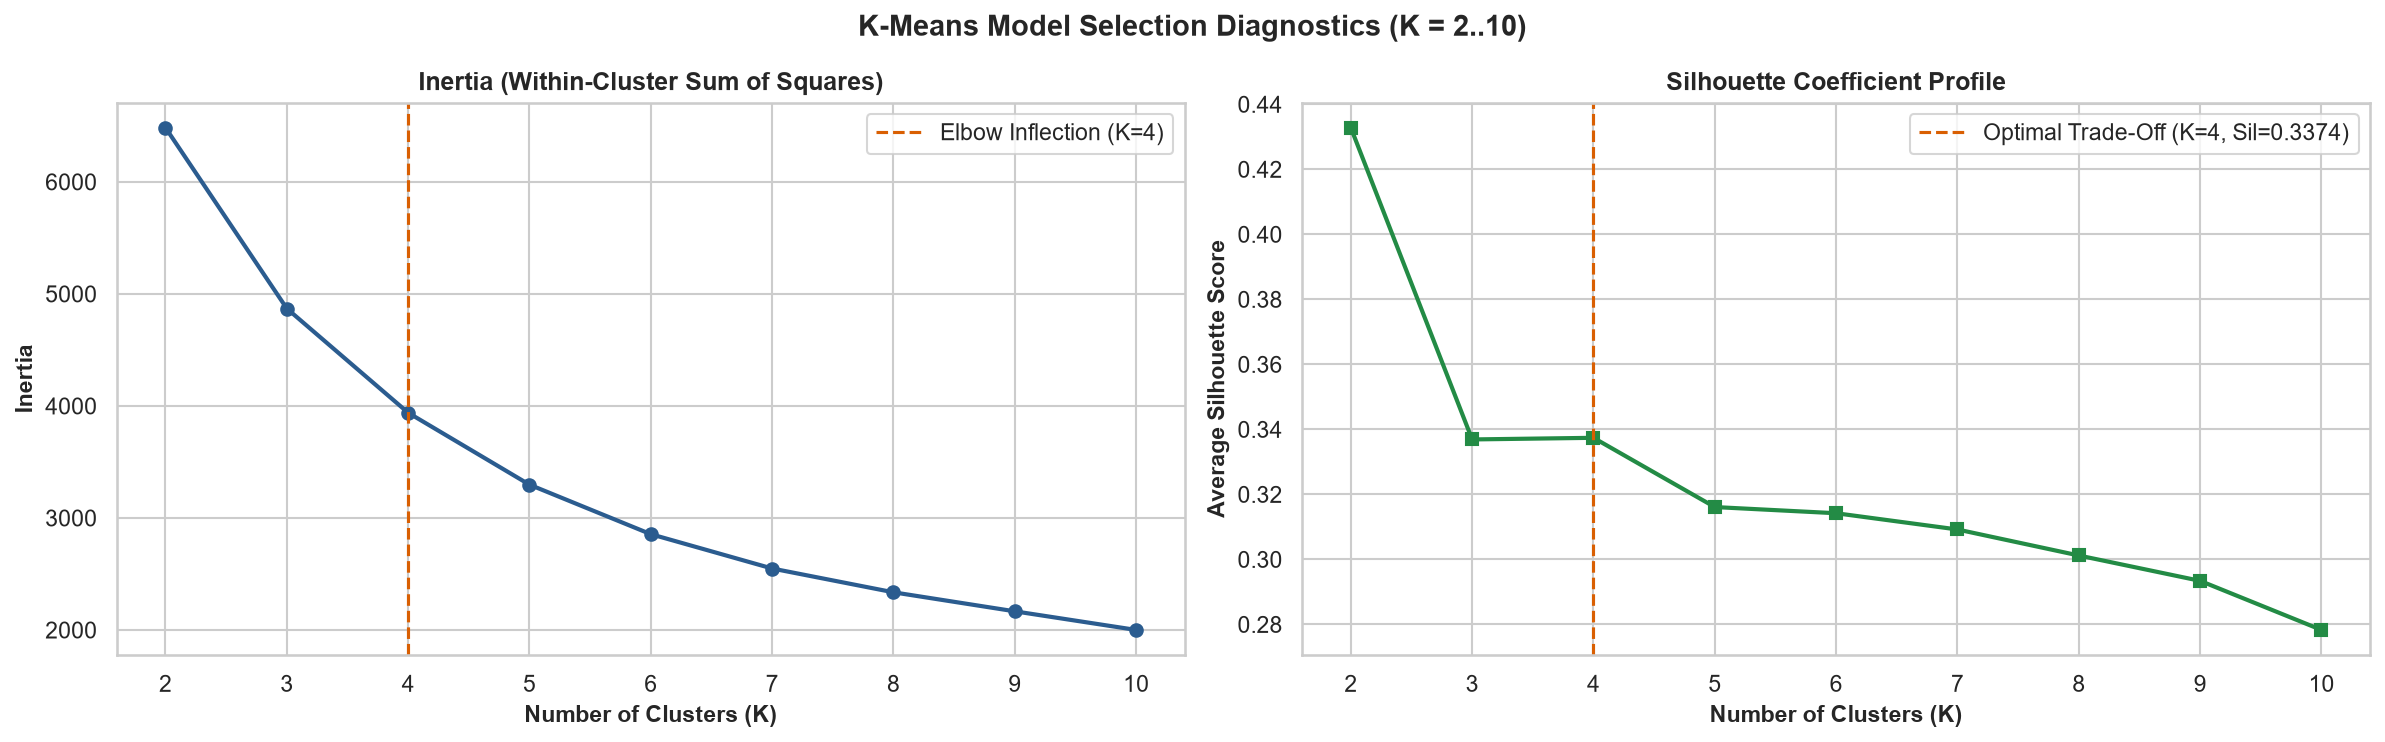

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("K-Means Model Selection Diagnostics (K = 2..10)", fontsize=14)

# 1. Inertia Elbow Plot
axes[0].plot(metrics_df["k"], metrics_df["inertia"], marker="o", linewidth=2, color="#2b5c8f")
axes[0].axvline(4, color="#d95f02", linestyle="--", label="Elbow Inflection (K=4)")
axes[0].set_title("Inertia (Within-Cluster Sum of Squares)")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(range(2, 11))
axes[0].legend()

# 2. Silhouette Score Plot
axes[1].plot(metrics_df["k"], metrics_df["silhouette_score"], marker="s", linewidth=2, color="#238b45")
axes[1].axvline(4, color="#d95f02", linestyle="--", label="Optimal Trade-Off (K=4, Sil=0.3374)")
axes[1].set_title("Silhouette Coefficient Profile")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Average Silhouette Score")
axes[1].set_xticks(range(2, 11))
axes[1].legend()

plt.tight_layout()
plt.show()


---

## 6. Documented Multi-Criteria $K$ Selection ($K = 4$)

### Trade-Off Evaluation Between Candidate $K$ Values:
- **Candidate $K = 2$ (Silhouette = 0.4328):** While $K=2$ yields the highest mathematical silhouette score, it merely separates the customer directory into active vs. inactive accounts (sizes 2,671 vs 1,667). This binary split fails to differentiate high-value wholesale accounts from mid-tier repeat shoppers, providing zero commercial utility for targeted CRM.
- **Candidate $K = 3$ (Silhouette = 0.3369, Inertia = 4,869.58):** Inertia remains elevated, and silhouette score is lower than $K=4$.
- **Candidate $K = 4$ (Silhouette = 0.3374, Inertia = 3,939.26):** **Selected as Optimal.**
  - **Pronounced Elbow Inflection:** Inertia drops significantly from $K=3$ (4,869.6) to $K=4$ (3,939.3) before gains plateau.
  - **Local Silhouette Peak:** Silhouette score rises from 0.3369 at $K=3$ to **0.3374 at $K=4$**, outperforming all $K \ge 5$.
  - **Exceptional Size Balance:** Cluster counts are `[716, 834, 1,170, 1,618]`. The smallest cluster contains 716 customers (16.5%), avoiding micro-cluster instability.
  - **Actionable Commercial Alignment:** Cleanly separates accounts into 4 fundamental behavioral tiers: *Power Buyers*, *Consistent Repeat Spenders*, *Recent / Developing Buyers*, and *Dormant / Low-Engagement Accounts*.
- **Candidate $K = 5$ (Silhouette = 0.3161, Inertia = 3,297.20):** Silhouette score drops sharply to 0.3161. One cluster fragments into an ultra-niche micro-cohort of 330 customers (7.6%), while two lower-tier clusters substantially overlap.


In [7]:
final_k = select_k(metrics_df)
print(f"Selected Optimal Cluster Count: K = {final_k}")

final_model = fit_kmeans(X_scaled, k=final_k, random_state=42, n_init=10)
clustered_df = generate_cluster_assignments(rfm_df, final_model, X_scaled)

print("Cluster membership distribution:")
display(clustered_df["cluster_id"].value_counts().sort_index().to_frame("customer_count"))


Selected Optimal Cluster Count: K = 4
Cluster membership distribution:


,customer_count
cluster_id,
0,834
1,1618
2,1170
3,716


---

## 7. Cluster Profiling & Quantitative Scorecard

We aggregate customer metrics by `cluster_id` to examine their real-world behavioral and financial properties:


CUSTOMERLENS K-MEANS CLUSTER BEHAVIORAL SCORECARD (K=4)


,cluster_id,customer_count,customer_percentage,total_revenue,revenue_percentage,average_recency,median_recency,average_frequency,median_frequency,average_monetary,median_monetary,average_orders,average_revenue_per_customer
0,0,834,19.23,465608.17,5.24,17.6,17.0,2.19,2.0,558.28,481.03,2.19,558.28
1,1,1618,37.30,547770.00,6.16,181.4,174.5,1.31,1.0,338.55,293.78,1.31,338.55
2,2,1170,26.97,2092321.70,23.54,72.1,57.0,4.06,4.0,1788.31,1340.08,4.06,1788.31
3,3,716,16.51,5781509.02,65.05,12.2,8.0,13.72,10.0,8074.73,3730.61,13.72,8074.73


C:\Users\divya\AppData\Local\Temp\ipykernel_20336\3136090822.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profiles_df, x="cluster_id", y="customer_percentage", palette=palette, ax=axes[0])
C:\Users\divya\AppData\Local\Temp\ipykernel_20336\3136090822.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profiles_df, x="cluster_id", y="revenue_percentage", palette=palette, ax=axes[1])


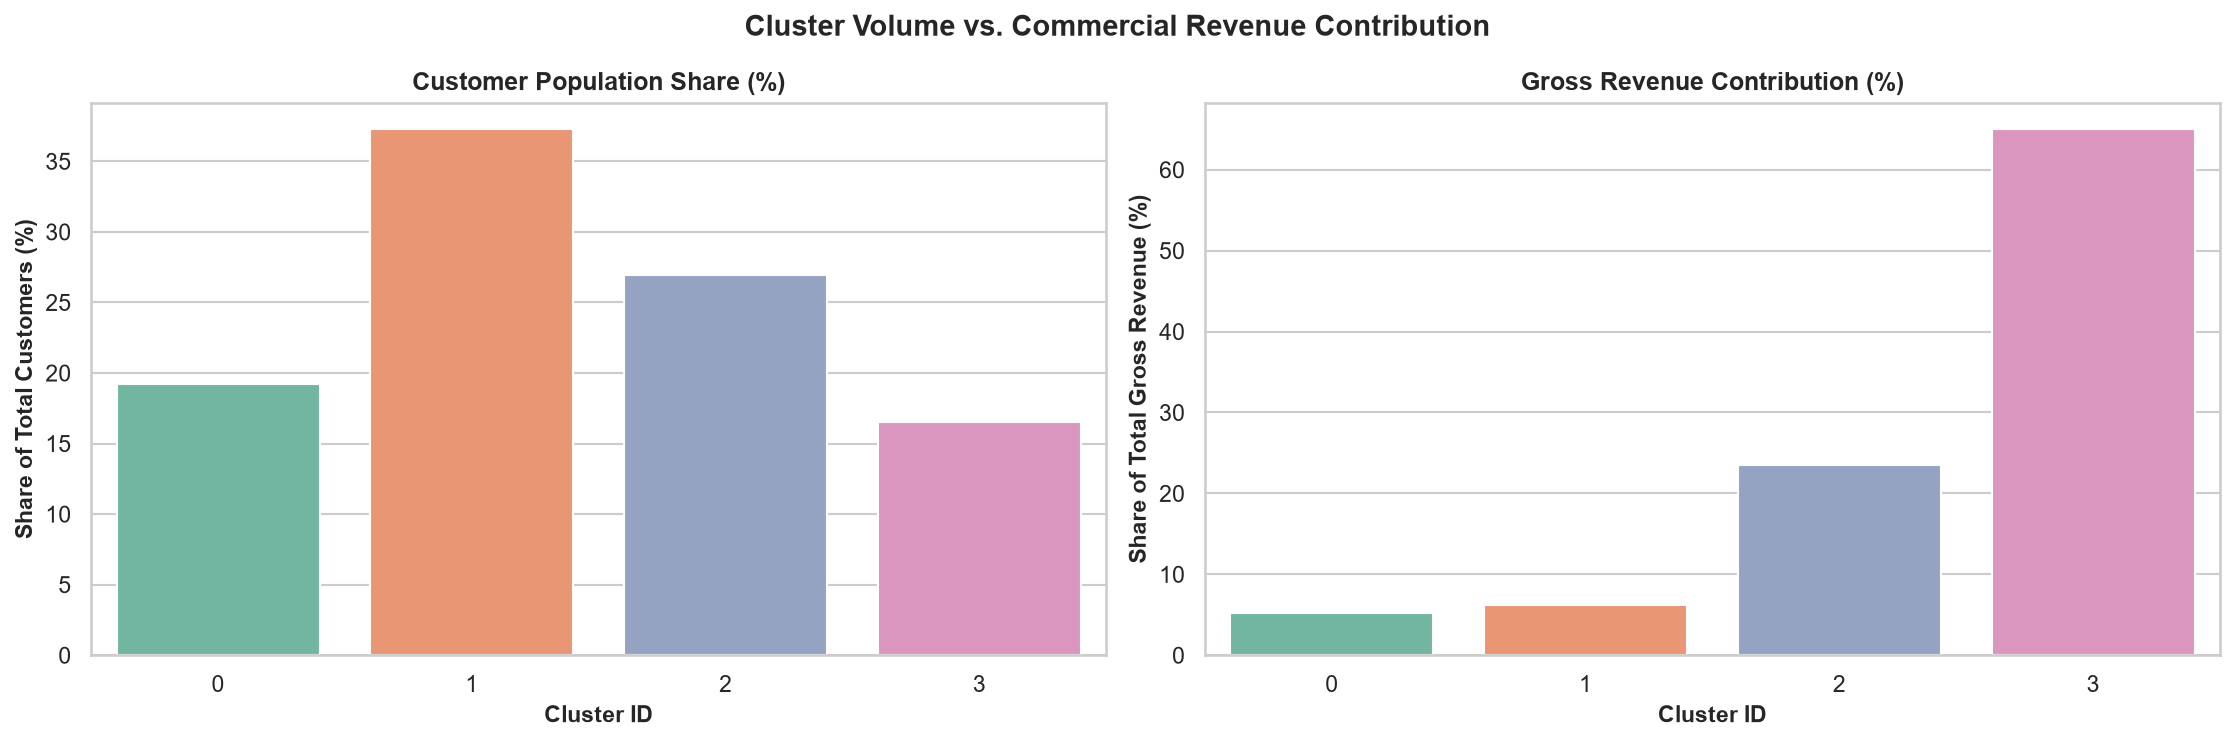

In [8]:
profiles_df = profile_clusters(clustered_df)

print("=" * 90)
print("CUSTOMERLENS K-MEANS CLUSTER BEHAVIORAL SCORECARD (K=4)")
print("=" * 90)
display(profiles_df)

# Visualizing Cluster Size and Revenue Contribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Cluster Volume vs. Commercial Revenue Contribution", fontsize=14)

palette = sns.color_palette("Set2", final_k)

sns.barplot(data=profiles_df, x="cluster_id", y="customer_percentage", palette=palette, ax=axes[0])
axes[0].set_title("Customer Population Share (%)")
axes[0].set_xlabel("Cluster ID")
axes[0].set_ylabel("Share of Total Customers (%)")

sns.barplot(data=profiles_df, x="cluster_id", y="revenue_percentage", palette=palette, ax=axes[1])
axes[1].set_title("Gross Revenue Contribution (%)")
axes[1].set_xlabel("Cluster ID")
axes[1].set_ylabel("Share of Total Gross Revenue (%)")

plt.tight_layout()
plt.show()


---

## 8. 2D Cluster Geometry & Behavioral Projections


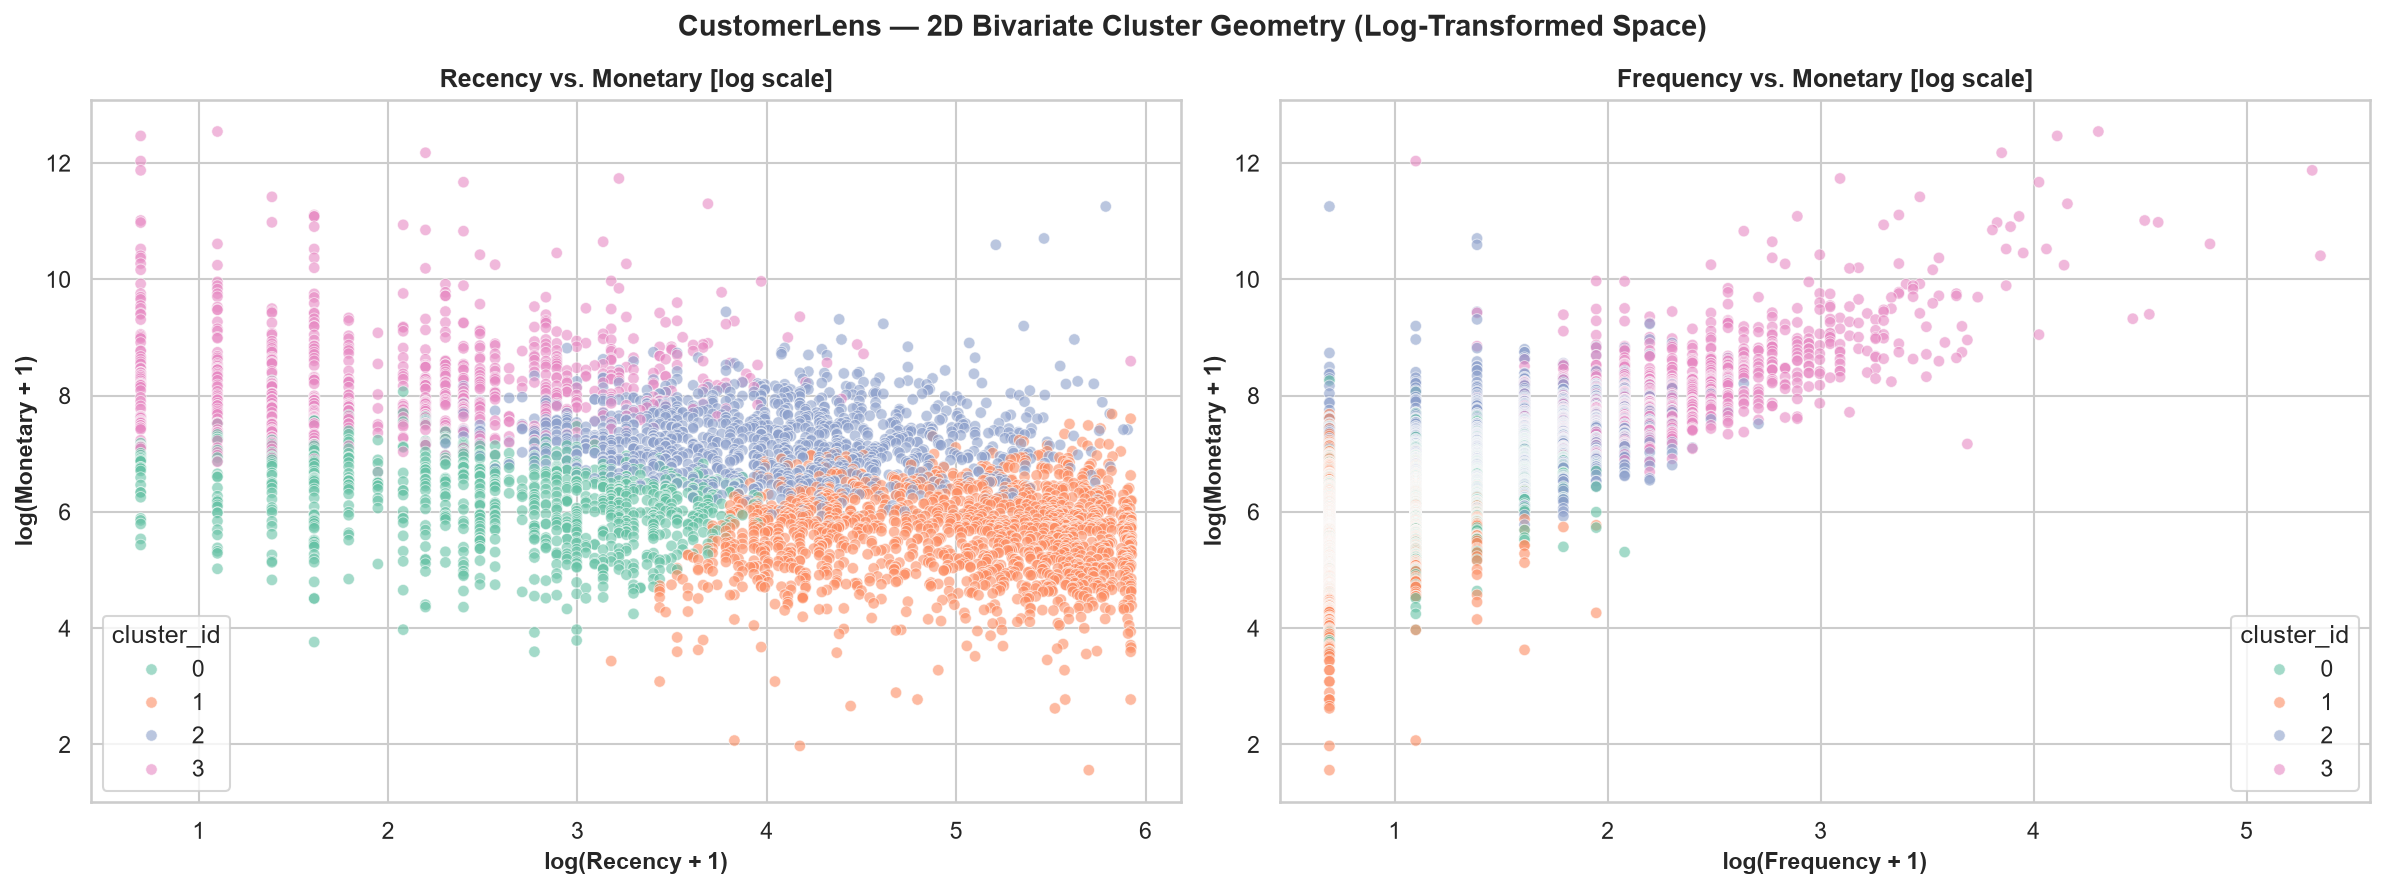

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("CustomerLens — 2D Bivariate Cluster Geometry (Log-Transformed Space)", fontsize=14)

# 1. Recency vs Monetary
sns.scatterplot(
    data=clustered_df,
    x=np.log1p(clustered_df["recency"]),
    y=np.log1p(clustered_df["monetary"]),
    hue="cluster_id",
    palette="Set2",
    alpha=0.6,
    s=30,
    ax=axes[0],
)
axes[0].set_title("Recency vs. Monetary [log scale]")
axes[0].set_xlabel("log(Recency + 1)")
axes[0].set_ylabel("log(Monetary + 1)")

# 2. Frequency vs Monetary
sns.scatterplot(
    data=clustered_df,
    x=np.log1p(clustered_df["frequency"]),
    y=np.log1p(clustered_df["monetary"]),
    hue="cluster_id",
    palette="Set2",
    alpha=0.6,
    s=30,
    ax=axes[1],
)
axes[1].set_title("Frequency vs. Monetary [log scale]")
axes[1].set_xlabel("log(Frequency + 1)")
axes[1].set_ylabel("log(Monetary + 1)")

plt.tight_layout()
plt.show()


---

## 9. 2D Principal Component Analysis (PCA) Projection

To inspect overall cluster separation without 3D rotation, we project the 3 standardized features onto the top 2 principal components.
*Note: PCA is applied strictly for 2D visual inspection; clustering itself was performed directly in the standardized 3D feature space.*


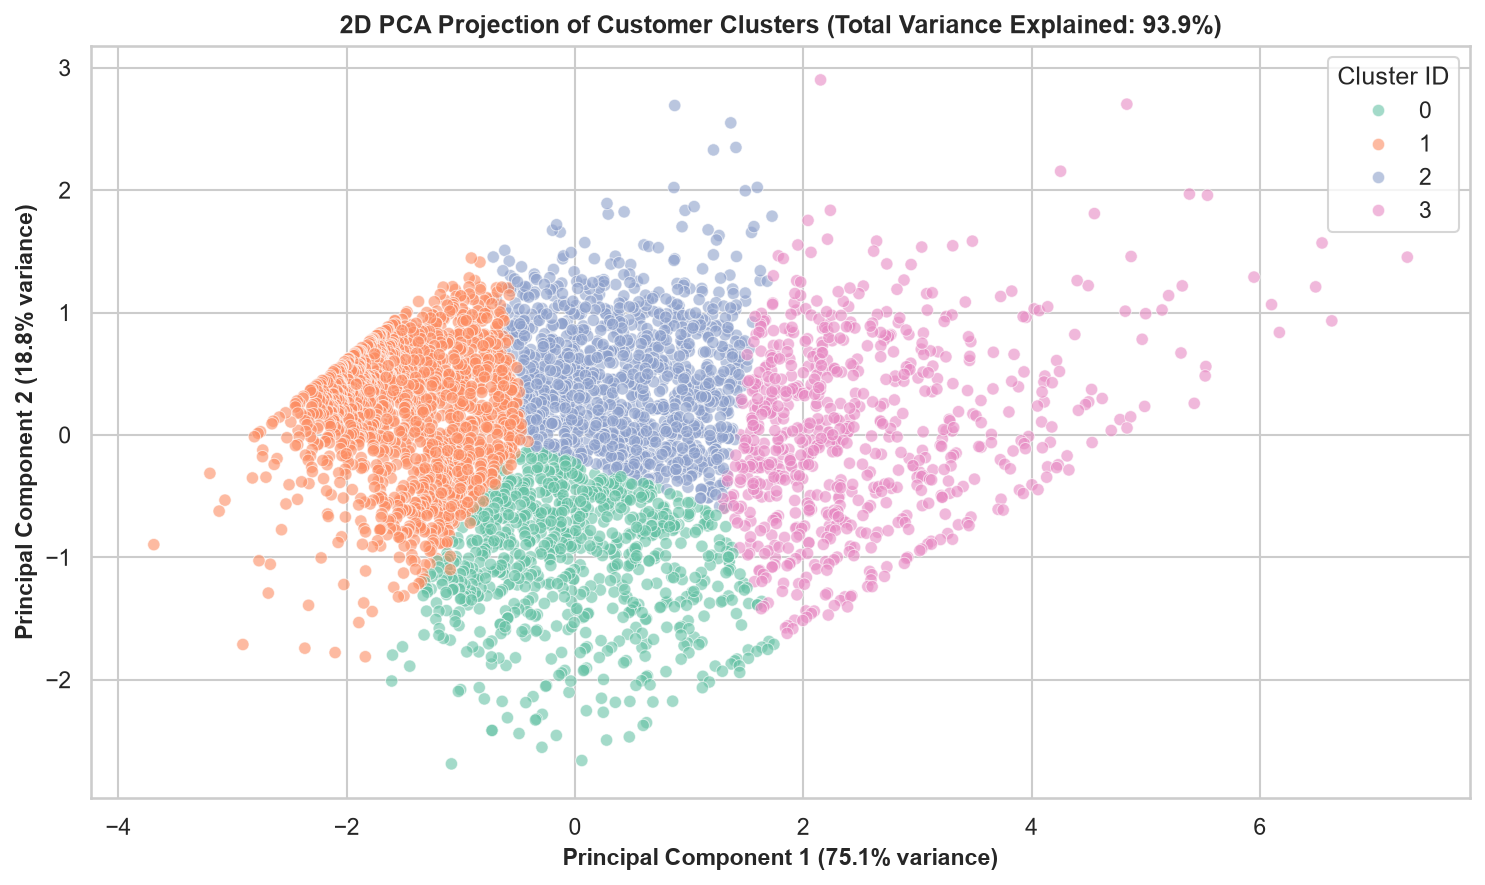

PCA Component 1 Variance Explained: 75.08%
PCA Component 2 Variance Explained: 18.79%
Cumulative Variance Explained      : 93.87%


In [10]:
pca = PCA(n_components=2, random_state=42)
pca_transformed = pca.fit_transform(X_scaled)
clustered_df["PCA1"] = pca_transformed[:, 0]
clustered_df["PCA2"] = pca_transformed[:, 1]

var_exp = pca.explained_variance_ratio_
total_var = var_exp.sum() * 100.0

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=clustered_df,
    x="PCA1",
    y="PCA2",
    hue="cluster_id",
    palette="Set2",
    alpha=0.6,
    s=35,
)
plt.title(f"2D PCA Projection of Customer Clusters (Total Variance Explained: {total_var:.1f}%)")
plt.xlabel(f"Principal Component 1 ({var_exp[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({var_exp[1]*100:.1f}% variance)")
plt.legend(title="Cluster ID")
plt.tight_layout()
plt.show()

print(f"PCA Component 1 Variance Explained: {var_exp[0]*100:.2f}%")
print(f"PCA Component 2 Variance Explained: {var_exp[1]*100:.2f}%")
print(f"Cumulative Variance Explained      : {total_var:.2f}%")


---

## 10. Behavioral Cluster Personas & Targeted Marketing Hypotheses

### Behavioral Interpretation of the 4 Clusters:
*(Note: Cluster IDs are arbitrary geometric identifiers and carry no inherent ranking; interpretations are derived strictly from empirical profiles).*

| Cluster ID | Descriptive Persona | Account Count (% Base) | Revenue Generated (% Total) | Median Recency | Median Frequency | Median Spend | Strategic Action Hypothesis |
| :---: | :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **Cluster 3** | **Key Accounts / Power Buyers** | 716 (16.5%) | **£5.78M (65.1%)** | **8 days** | **10 orders** | **£4,358** | Dedicated VIP account managers, priority fulfillment, personalized volume discounts. |
| **Cluster 2** | **Consistent Repeat Spenders** | 1,170 (27.0%) | **£2.09M (23.5%)** | **57 days** | **4 orders** | **£1,304** | Loyalty reward tiers, cross-category recommendations, replenishment triggers. |
| **Cluster 0** | **Recent / Developing Buyers** | 834 (19.2%) | **£466k (5.2%)** | **17 days** | **2 orders** | **£430** | Onboarding nurture sequences, basket-building incentives, second-order nudges. |
| **Cluster 1** | **Dormant / Low-Engagement** | 1,618 (37.3%) | **£548k (6.2%)** | **175 days** | **1 order** | **£241** | Automated win-back campaigns, clearance promotions (test via controlled A/B trial). |

---

### Analytical Limitations & Governance Guardrails:
1. **No Demographic or Psychographic Data:** Clusters reflect purchase event timing and volume only.
2. **No Campaign or Attribution Records:** We cannot observe customer acquisition source or prior marketing touches.
3. **Hypothesis-Driven Recommendations:** Suggested marketing initiatives are commercial hypotheses requiring validation via randomized controlled experiments (A/B testing).


In [11]:
# Save all clustering outputs
saved = save_clustering_outputs(clustered_df, profiles_df, metrics_df)

print("=" * 60)
print("PHASE 9 OUTPUT PERSISTENCE SUMMARY")
print("=" * 60)
for k, path in saved.items():
    print(f"Saved {k:20}: {path}")
print("=" * 60)
print("Phase 9 Customer Segmentation Pipeline completed successfully!")


PHASE 9 OUTPUT PERSISTENCE SUMMARY
Saved customer_clusters   : C:\Users\divya\OneDrive\Desktop\Customer_Lens\data\processed\customer_clusters.csv
Saved cluster_profiles    : C:\Users\divya\OneDrive\Desktop\Customer_Lens\data\processed\cluster_profiles.csv
Saved clustering_metrics  : C:\Users\divya\OneDrive\Desktop\Customer_Lens\data\processed\clustering_metrics.csv
Phase 9 Customer Segmentation Pipeline completed successfully!
